## Objectives

This notebook develops forecasting models to predict future product demand.

The following models will be implemented:

- Moving Average Forecast
- ARIMA Forecast

The models will be evaluated using:

- RMSE
- MAPE

Finally, a 90-day demand forecast will be generated.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [11]:
df = pd.read_csv(
    "Project 2/data/processed/clean_sales.csv",
    parse_dates=["date"]
)

df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [12]:
df.set_index("date", inplace=True)

In [13]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1826 entries, 2019-01-01 to 2023-12-31
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   store_id  1826 non-null   str    
 1   item_id   1826 non-null   str    
 2   sales     1826 non-null   int64  
 3   price     1826 non-null   float64
 4   promo     1826 non-null   int64  
 5   weekday   1826 non-null   int64  
 6   month     1826 non-null   int64  
dtypes: float64(1), int64(4), str(2)
memory usage: 137.3 KB


In [14]:
df.describe()

,sales,price,promo,weekday,month
count,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000
mean,44.780942,20.870734,0.100767,3.001643,6.523549
std,13.761220,1.282695,0.301102,1.999862,3.449478
min,16.000000,17.040000,0.000000,0.000000,1.000000
25%,35.000000,21.300000,0.000000,1.000000,4.000000
50%,43.000000,21.300000,0.000000,3.000000,7.000000
75%,53.000000,21.300000,0.000000,5.000000,10.000000
max,107.000000,21.300000,1.000000,6.000000,12.000000


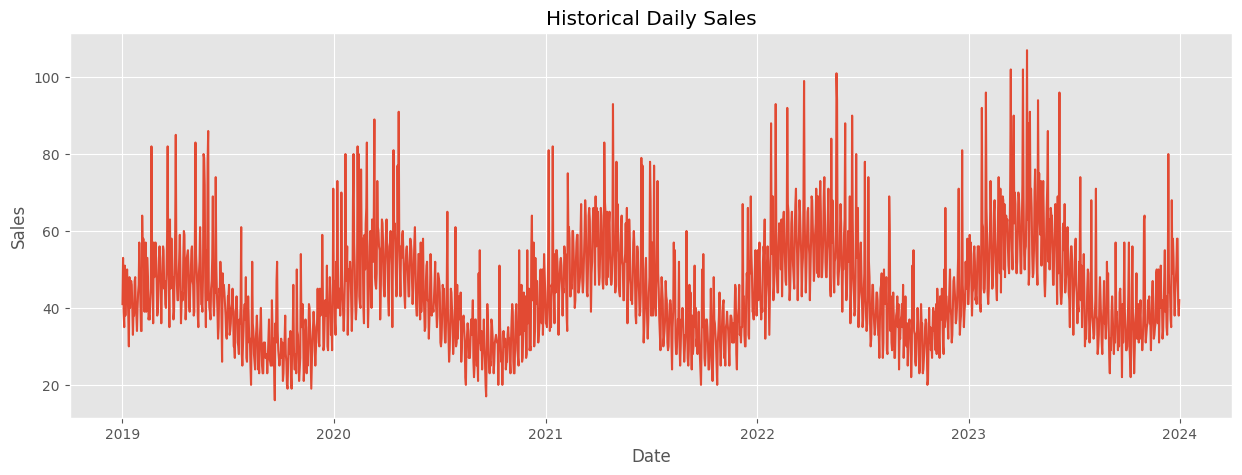

In [15]:
plt.figure(figsize=(15,5))

plt.plot(
    df.index,
    df["sales"]
)

plt.title("Historical Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [16]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]

test = df.iloc[train_size:]

In [17]:
print("Training Records:", len(train))
print("Testing Records :", len(test))

Training Records: 1460
Testing Records : 366


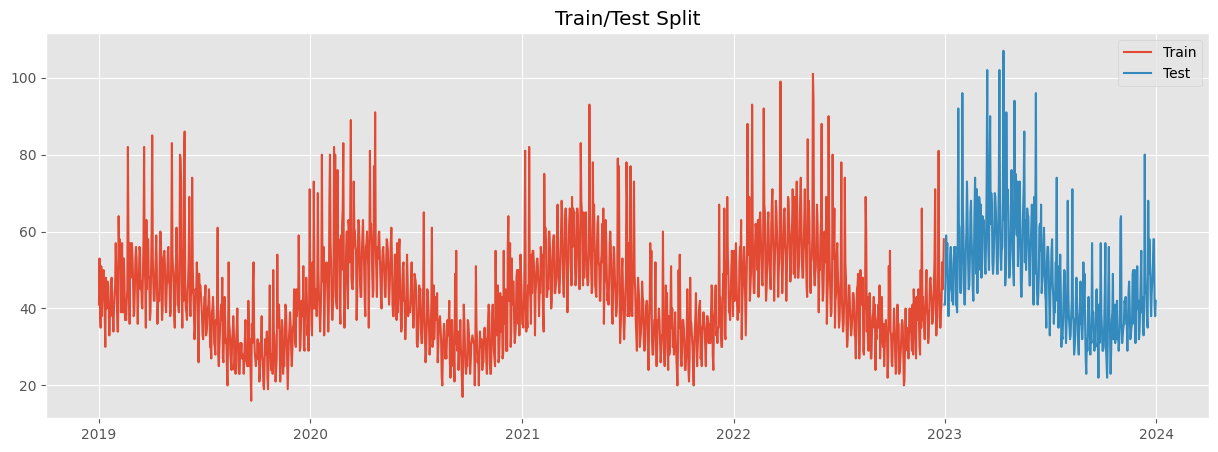

In [18]:
plt.figure(figsize=(15,5))

plt.plot(
    train.index,
    train["sales"],
    label="Train"
)

plt.plot(
    test.index,
    test["sales"],
    label="Test"
)

plt.legend()

plt.title("Train/Test Split")

plt.show()